<a href="https://colab.research.google.com/github/james-kidd/manager-dna/blob/initial-project-setup/notebooks/manager_dna_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manager DNA: Active ETF Behavioral Analysis

**Project Goal:** Reverse-engineer the behavioral DNA of active ETF managers using:
1. **Fama-French 5-Factor** rolling regressions (dimensionality reduction)
2. **Gaussian Mixture Model** regime classification (market state detection)
3. **PCA + Bipartite Network** clustering (managerial archetype mapping)

**Math & CS Foundations:**
- OLS regression, Rolling windows, Active return decomposition
- GMM: $p(X_t) = \sum_{k=1}^{K} \pi_k \mathcal{N}(X_t \mid \mu_k, \Sigma_k)$
- PCA on covariance matrix of factor loadings
- Bipartite graph $G = (U, V, E)$ where $U$ = Funds, $V$ = Super-Styles

---

## 0. Setup
Clone the repo, install dependencies, and mount Google Drive for persistent output.

In [1]:
# -- Colab setup (skip if local) --
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    !git clone https://github.com/james-kidd/manager-dna.git
    %cd manager-dna
    !pip install -e ".[notebook]" -q
else:
    # Local: just make sure you've run `pip install -e .` from the project root
    pass

import sys
sys.path.insert(0, 'src')

Cloning into 'manager-dna'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 40 (delta 9), reused 38 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 26.17 KiB | 5.23 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/manager-dna
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.0 MB/s eta 0:00:00
  Building editable for manager-dna (pyproject.toml) ... done


In [2]:
# -- Mount Google Drive for persistent output --
from google.colab import drive
drive.mount('/content/drive')

DRIVE_OUTPUT = '/content/drive/MyDrive/manager-dna/output'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f'Outputs will be saved to Google Drive: {DRIVE_OUTPUT}')

Mounted at /content/drive
Outputs will be saved to Google Drive: /content/drive/MyDrive/manager-dna/output


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

from manager_dna import ManagerialFactorExtractor, MarketRegimeModel, ManagerialDNAMapper
from manager_dna.factor_extraction import FF_FACTORS

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100

In [4]:
# Load config (edit config.yaml to change parameters)
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Point outputs to Google Drive so they persist across sessions
cfg['output']['dir'] = DRIVE_OUTPUT
print('Config loaded. Fund universe:', cfg['fund_universe'])
print(f'Output dir: {cfg["output"]["dir"]}')

Config loaded. Fund universe: ['ARKK', 'QQQ', 'SCHD', 'VTV', 'MTUM']
Output dir: /content/drive/MyDrive/manager-dna/output


## Stage 1: Fama-French Active Factor Extraction

For each fund, we compute:
$$\Delta R_{f,t} = \alpha_f + \beta_1(\text{MKT-RF}) + \beta_2(\text{SMB}) + \beta_3(\text{HML}) + \beta_4(\text{RMW}) + \beta_5(\text{CMA}) + \epsilon$$

using a **rolling OLS** window (default 63 trading days = 1 quarter).

In [5]:
fcfg = cfg['factor_extraction']
fund_universe = cfg['fund_universe']

all_loadings = {}
for ticker in fund_universe:
    print(f'\n--- {ticker} ---')
    ext = ManagerialFactorExtractor(
        fund_ticker=ticker,
        benchmark_ticker=fcfg['benchmark_ticker'],
        start_date=fcfg['start_date'],
        window=fcfg['rolling_window'],
    )
    try:
        ext.fetch_data()
        loadings = ext.extract_rolling_factors()
        all_loadings[ticker] = loadings
    except Exception as e:
        print(f'SKIP {ticker}: {e}')

print(f'\nSuccessfully processed {len(all_loadings)}/{len(fund_universe)} funds.')


--- ARKK ---
Fetching data for ARKK vs SPY...


[*********************100%***********************]  2 of 2 completed


Fetching Fama-French 5-Factor Daily Data...
Data merged: 2071 trading days.
Running rolling FF regression (window=63 days)...


[                       0%                       ]

Factor extraction complete: 2009 observations.

--- QQQ ---
Fetching data for QQQ vs SPY...


...

Fetching Fama-French 5-Factor Daily Data...
Data merged: 2071 trading days.
Running rolling FF regression (window=63 days)...


[                       0%                       ]

Factor extraction complete: 2009 observations.

--- MTUM ---
Fetching data for MTUM vs SPY...


[*********************100%***********************]  2 of 2 completed


Fetching Fama-French 5-Factor Daily Data...
Data merged: 2071 trading days.
Running rolling FF regression (window=63 days)...
Factor extraction complete: 2009 observations.

Successfully processed 5/5 funds.


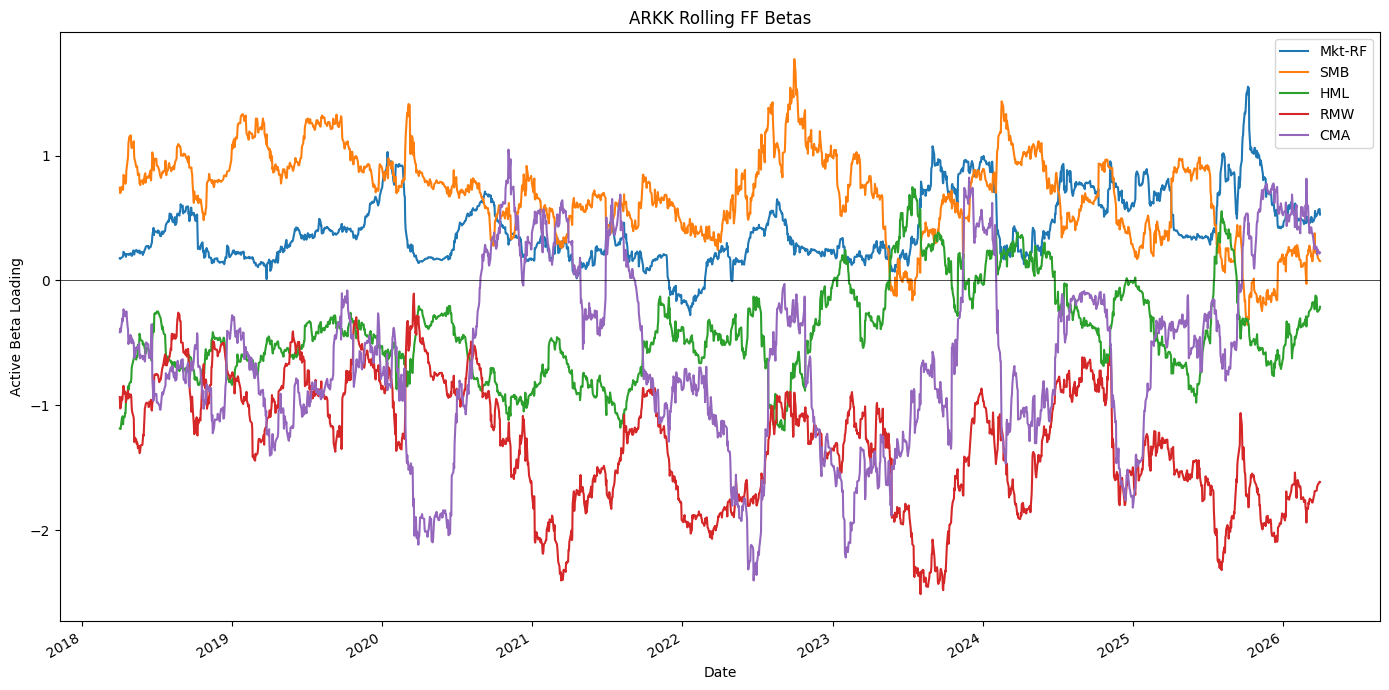

In [6]:
# Visualize rolling betas for the first fund
first_ticker = list(all_loadings.keys())[0]
ax = all_loadings[first_ticker][FF_FACTORS].plot(title=f'{first_ticker} Rolling FF Betas')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Active Beta Loading')
plt.tight_layout()
plt.show()

## Stage 2: GMM Regime Modeling

Fit a Gaussian Mixture Model over macro features to classify market regimes:
$$p(X_t) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(X_t \mid \mu_k, \Sigma_k)$$

Features: SPY return, VIX level, HY credit spread, 10Y yield change.

In [7]:
rcfg = cfg['regime_model']
regime = MarketRegimeModel(
    start_date=rcfg['start_date'],
    n_regimes=rcfg['n_regimes'],
)
regime.fetch_macro_data()
regime_data = regime.fit_predict_regimes()

print('\nRegime characteristics:')
regime.get_regime_summary()

Fetching market and macro data...


[*********************100%***********************]  2 of 2 completed


Macro data merged: 706 trading days.
Fitting GMM with 3 hidden regimes...

Regime characteristics:


,SPY_Return,VIX_Level,Credit_Spread,10Y_Yield_Change
Regime,,,,
0,-0.002859,24.443190,3.337500,-0.006293
1,0.001994,16.136779,2.979255,-0.000505
2,0.000886,14.965920,3.961839,0.006034


In [8]:
regime.plot_regimes(save_path=os.path.join(cfg['output']['dir'], cfg['output']['regime_plot']))

Regime plot saved: /content/drive/MyDrive/manager-dna/output/market_regimes_gmm.png


## Combine: Aggregate Betas by Regime

For each (fund, regime) pair, compute the **mean active beta** across all trading days in that regime. This produces the input matrix for PCA.

In [9]:
regime_labels = regime_data['Regime']
rows = []

for ticker, loadings in all_loadings.items():
    common = loadings.index.intersection(regime_labels.index)
    if len(common) == 0:
        continue
    merged = loadings.loc[common].copy()
    merged['Regime'] = regime_labels.loc[common]
    for r in range(rcfg['n_regimes']):
        sl = merged[merged['Regime'] == r]
        if len(sl) > 0:
            avg = sl[FF_FACTORS].mean()
            avg.name = f'{ticker}_R{r}'
            rows.append(avg)

df_agg = pd.DataFrame(rows)
print(f'Aggregated matrix: {df_agg.shape}')
df_agg

Aggregated matrix: (15, 5)


,Mkt-RF,SMB,HML,RMW,CMA
ARKK_R0,0.593871,0.473958,-0.437859,-1.452436,-0.162653
ARKK_R1,0.612528,0.528582,-0.187944,-1.478351,-0.426847
ARKK_R2,0.634461,0.444454,0.208801,-1.782979,-0.576946
QQQ_R0,0.169916,-0.072391,-0.246479,-0.073835,-0.126848
QQQ_R1,0.192454,-0.077194,-0.213066,-0.046903,-0.175752
QQQ_R2,0.136593,-0.060042,-0.186781,0.035804,-0.595404
SCHD_R0,-0.347467,0.149182,0.421959,0.102157,0.358372
SCHD_R1,-0.314006,0.202213,0.386617,0.038983,0.370724
SCHD_R2,-0.072277,0.083283,0.232153,0.003390,0.550446
VTV_R0,-0.233938,0.081138,0.364374,-0.042749,0.213994


## Stage 3: PCA Super-Styles & Bipartite Network

Extract orthogonal "Super-Styles" via PCA, then build a bipartite graph:
$$G = (U, V, E) \quad \text{where } U = \text{Funds}, \; V = \text{Super-Styles (PCs)}, \; E = \text{PCA loading}$$

In [10]:
dcfg = cfg['dna_mapper']
n_comp = min(dcfg['n_components'], len(df_agg))

mapper = ManagerialDNAMapper(n_components=n_comp)
fund_pca, super_styles = mapper.extract_super_styles(df_agg)

print('\nSuper-Style compositions (what each PC loads on):')
display(super_styles)

print('\nFund-regime DNA loadings:')
display(fund_pca)

Running PCA to extract top 2 Super-Styles...
Variance explained: [0.65347501 0.24809827]

Super-Style compositions (what each PC loads on):


,Mkt-RF,SMB,HML,RMW,CMA
Style_PC1,0.541741,0.337994,-0.381875,-0.501287,-0.441768
Style_PC2,-0.071054,0.677940,0.531253,-0.346145,0.365106



Fund-regime DNA loadings:


,Style_PC1,Style_PC2
ARKK_R0,3.235906,0.531762
ARKK_R1,3.327018,0.961544
ARKK_R2,3.082039,1.512145
QQQ_R0,0.195209,-1.472312
QQQ_R1,0.213843,-1.488428
QQQ_R2,0.537178,-1.825731
SCHD_R0,-2.027138,1.075343
SCHD_R1,-1.797231,1.213551
SCHD_R2,-1.531878,0.664105
VTV_R0,-1.567946,0.656562


In [11]:
network = mapper.build_bipartite_network(edge_threshold=dcfg['edge_threshold'])
mapper.visualize_network(
    network,
    save_path=os.path.join(cfg['output']['dir'], cfg['output']['network_plot'])
)

Constructing bipartite DNA network...
Network plot saved: /content/drive/MyDrive/manager-dna/output/managerial_dna_network.png


## Results Interpretation

- **Blue edges** = fund loads *positively* on that Super-Style (long tilt)
- **Red dashed edges** = fund loads *negatively* (short/underweight tilt)
- **Edge thickness** = conviction strength (absolute PCA loading)
- **Funds clustering to the same PC** across regimes = consistent style
- **Funds shifting between PCs** across regimes = tactical/drifting manager

### Next Steps
- [ ] Add Hull delta-equivalent adjustment for options-holding funds
- [ ] Implement style drift detection (graph topology change between regimes)
- [ ] Add more funds to `config.yaml` → `fund_universe`
- [ ] Export results to interactive Plotly/D3 visualization